# Анализ интерполяции

В этом блокноте мы оценим качество интерполированных сигналов и сделаем выводы о влиянии метода интерполяции и частоты сигнала при фиксированной дискретизации.

*+анализ ошибки квантования по данным, полученным с вывода программы yadro_test_rfc для тестовых данных*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

Функции для построения графиков, на основе которых будем делать анализ:

In [2]:
DATA_FOLDER = Path('build/data')

def load_signal(filename: str):
    """Загружает CSV: 1-я строка - время, 2-я строка - значения сигнала"""
    if not filename.endswith('.csv'):
        filename += '.csv'
    
    filepath = DATA_FOLDER / filename
    if not filepath.exists():
        print(f"file doesn't exist: {filename}")
        return None, None
    
    df = pd.read_csv(filepath, header=None)
    time = df.iloc[0, :].values
    signal = df.iloc[1, :].values
    return time, signal


def compare_interpolation(frequencies=None):
    """Строит графики интерполированных сигналов и эталонных (на частоте 200гц)"""
    if frequencies is None:
        frequencies = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 45.0, 49.0]
    
    for freq in frequencies:
        base = f"{freq:.1f}hz_from_0.0_to_1.0"
        
        # Загрузка данных
        t100, orig100  = load_signal(f"{freq:.1f}hz_from_0.0_to_1.0_signal")
        t200, ideal200 = load_signal(base + "_ref_200")
        _, sinc = load_signal(base + "_sinc")
        _, lin_fixed = load_signal(base + "_lin_fixed")
        _, quantized200 = load_signal(base + "_ref_quantized_200")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'interpolation - {freq} hz', fontsize=16)
        
        ax1.plot(t100, orig100, 'o', color='blue', markersize=4, label='orig signal (100 hz)')
        ax1.plot(t200[:len(sinc)], sinc, '-', color='red', linewidth=2.0, label='sinc-interpolation')
        ax1.plot(t200[1:len(sinc):2], sinc[1::2], 'x', color='darkred',
                 markersize=6, label='interpolated points')
        ax1.set_title('sinc-interpolation with orig signal')
        ax1.set_xlabel('time')
        ax1.set_ylabel('amplitude')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(t200[:len(quantized200)], quantized200, 'o', color='purple', 
                 markersize=4, label='quantized 200 hz')
        ax2.plot(t200[:len(lin_fixed)], lin_fixed, '-', color='green', linewidth=2.0, 
                 label='linear fixed-point interpolation')
        ax2.plot(t200[1:len(lin_fixed):2], lin_fixed[1::2], 'x', color='darkgreen',
                 markersize=6, label='interpolated points')
        ax2.set_title('linear interpolation with orig fixed-point signal')
        ax2.set_xlabel('time')
        ax2.set_ylabel('amplitude')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def plot_fft_comparison(frequencies=None):
    """Строит графики БПФ интерполированных сигналов и эталонных (на частоте 200гц)"""
    if frequencies is None:
        frequencies = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 45.0, 49.0]
    
    for freq in frequencies:
        base = f"{freq:.1f}hz_from_0.0_to_1.0"
        
        # Загрузка данных
        _, ideal = load_signal(base + "_ref_200")
        _, sinc = load_signal(base + "_sinc")
        _, lin_fixed = load_signal(base + "_lin_fixed")
        _, quantized = load_signal(base + "_ref_quantized_200")
        
        fs = 200.0
        N = len(ideal)
        
        freqs = np.fft.rfftfreq(N, 1/fs)
        
        # FFT
        fft_ideal = np.abs(np.fft.rfft(ideal))
        fft_sinc  = np.abs(np.fft.rfft(sinc[:N]))
        fft_lin   = np.abs(np.fft.rfft(lin_fixed[:N]))
        fft_quant = np.abs(np.fft.rfft(quantized))
        
        # Нормализация
        fft_ideal /= np.max(fft_ideal)
        fft_sinc  /= np.max(fft_sinc)
        fft_lin   /= np.max(fft_lin)
        fft_quant /= np.max(fft_quant)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'FFT — {freq} hz', fontsize=16)
        
        # Левый график - sinc
        ax1.plot(freqs, fft_ideal, 'b-', linewidth=3, label='ideal')
        ax1.plot(freqs, fft_sinc, 'r--', linewidth=3, label='sinc')
        ax1.set_title('sinc')
        ax1.set_xlabel('frequency, hz')
        ax1.set_ylabel('normalized nmplitude')
        ax1.set_xlim(0, 100)
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Правый график - linear fixed-point
        ax2.plot(freqs, fft_quant, 'purple', linewidth=3, label='quantized 200Hz')
        ax2.plot(freqs, fft_lin, 'g--', linewidth=3, label='linear fixed-point')
        ax2.set_title('linear fixed-point')
        ax2.set_xlabel('frequency, hz')
        ax2.set_ylabel('normalized amplitude')
        ax2.set_xlim(0, 100)
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

Построим графики сигналов:

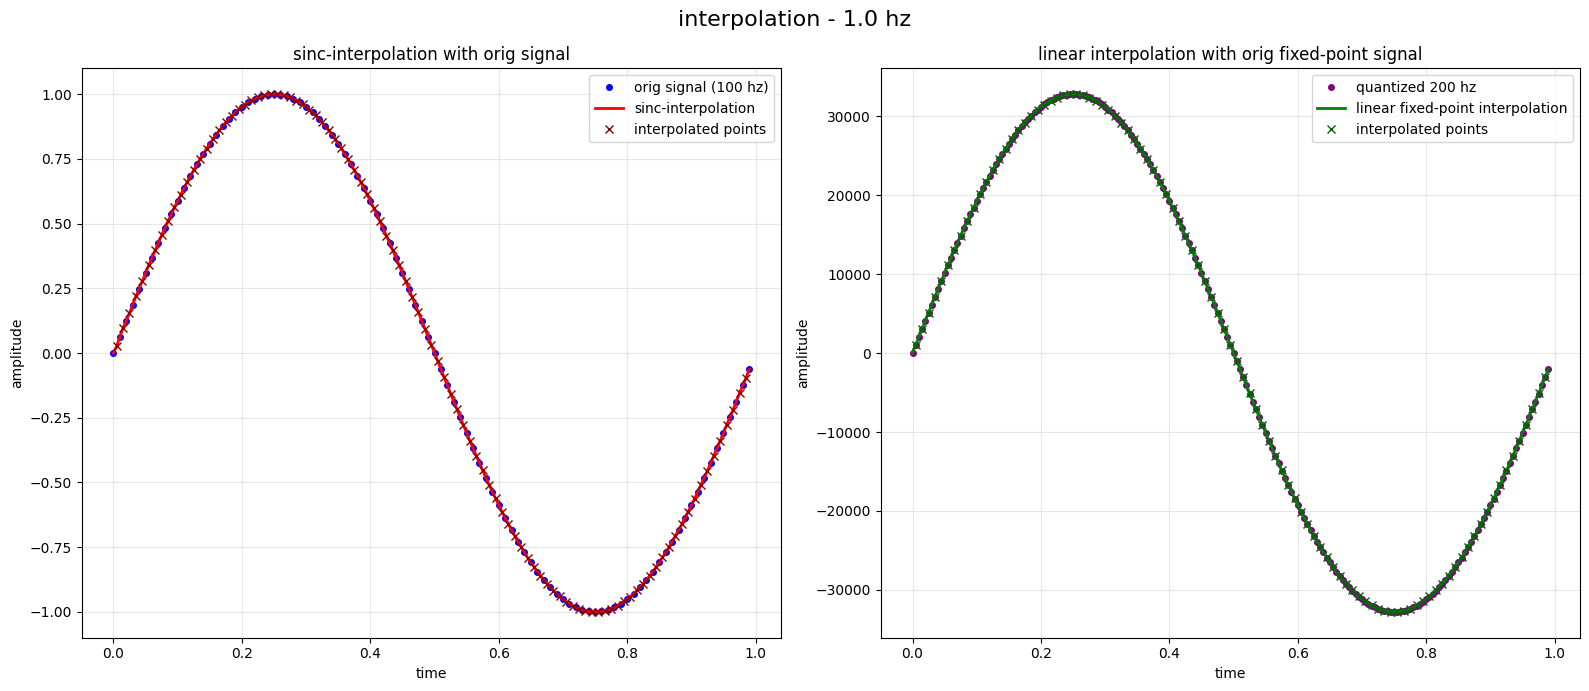

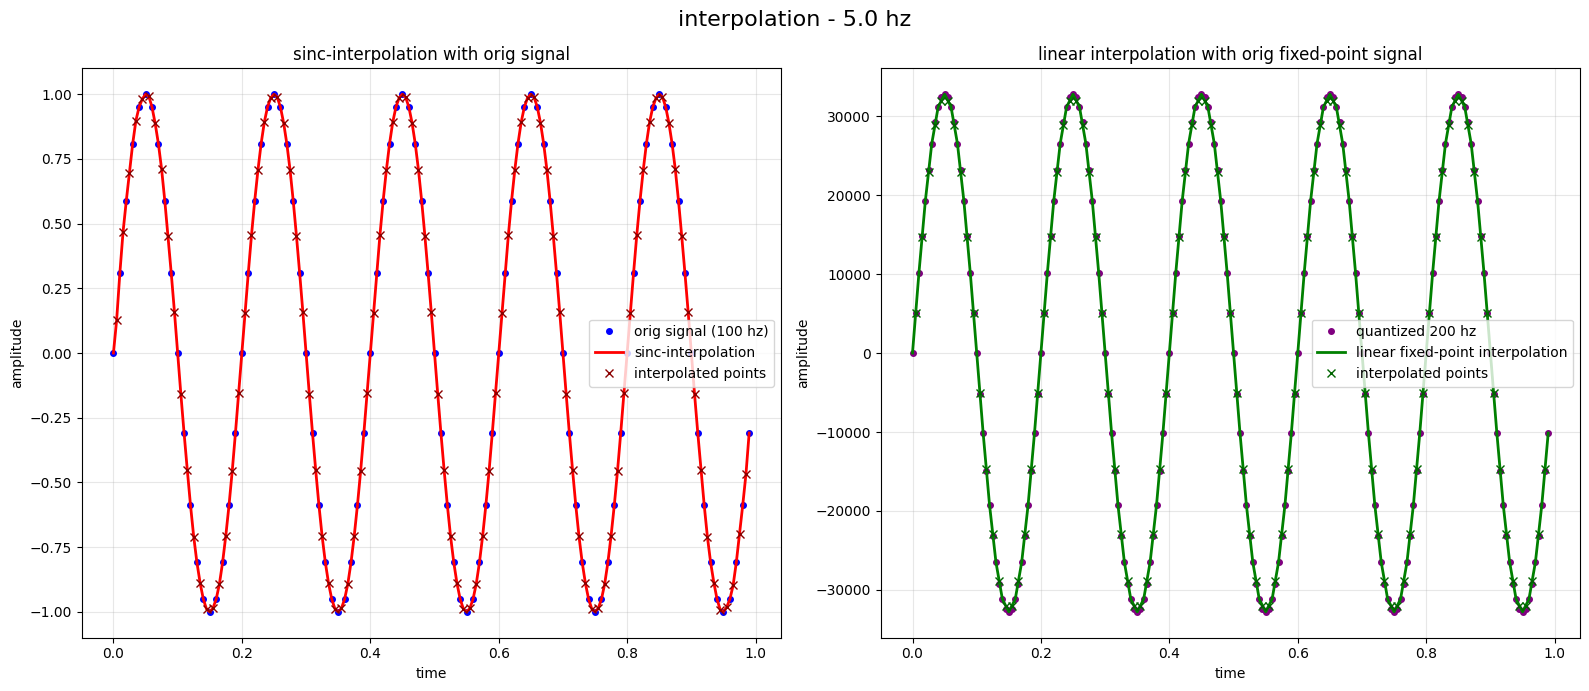

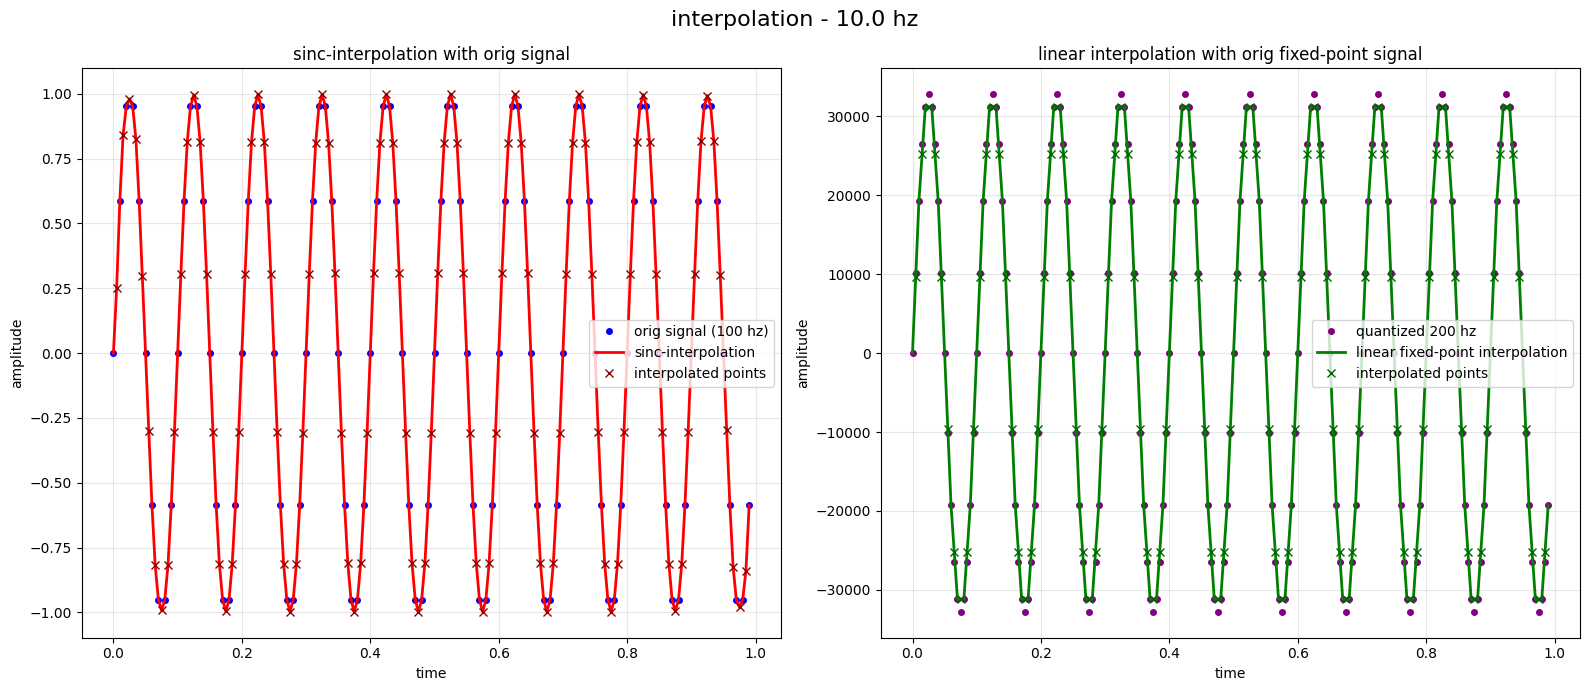

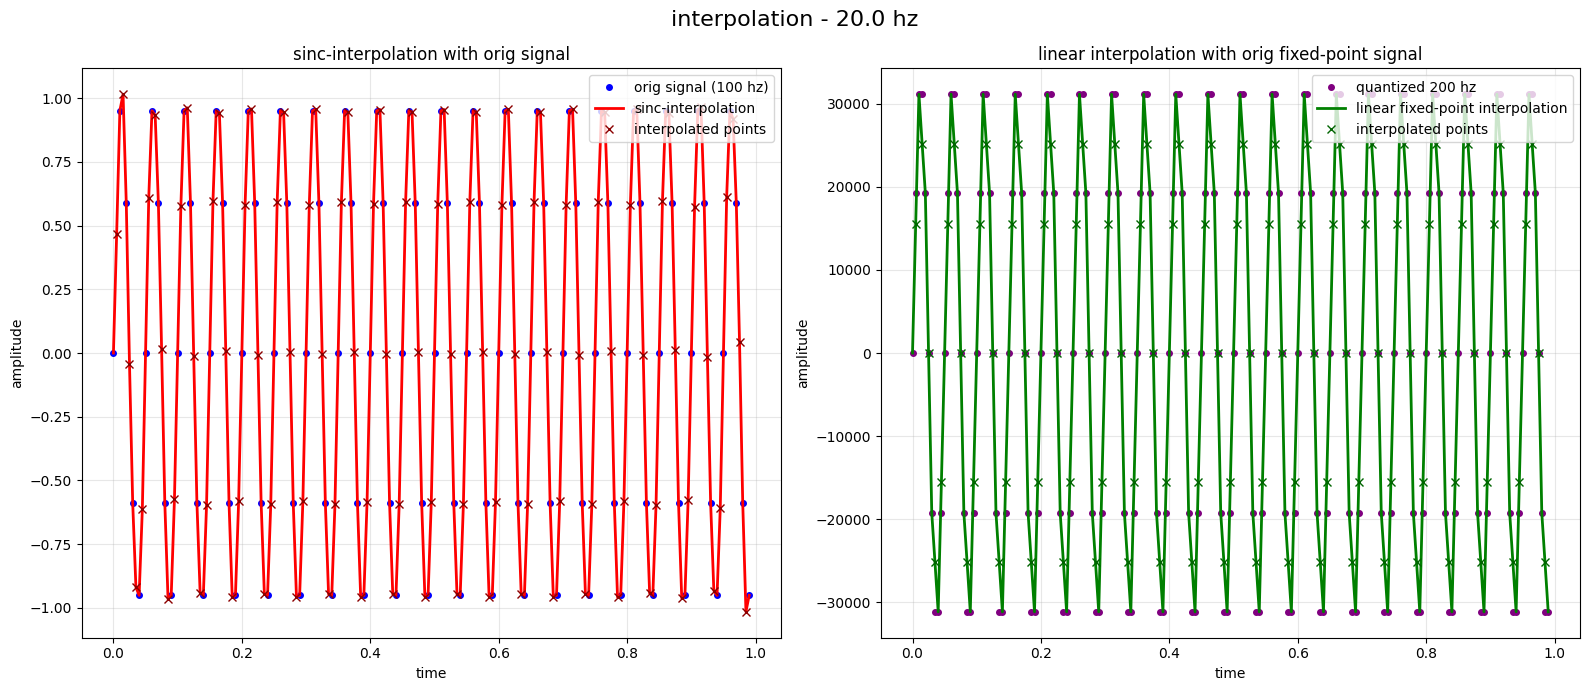

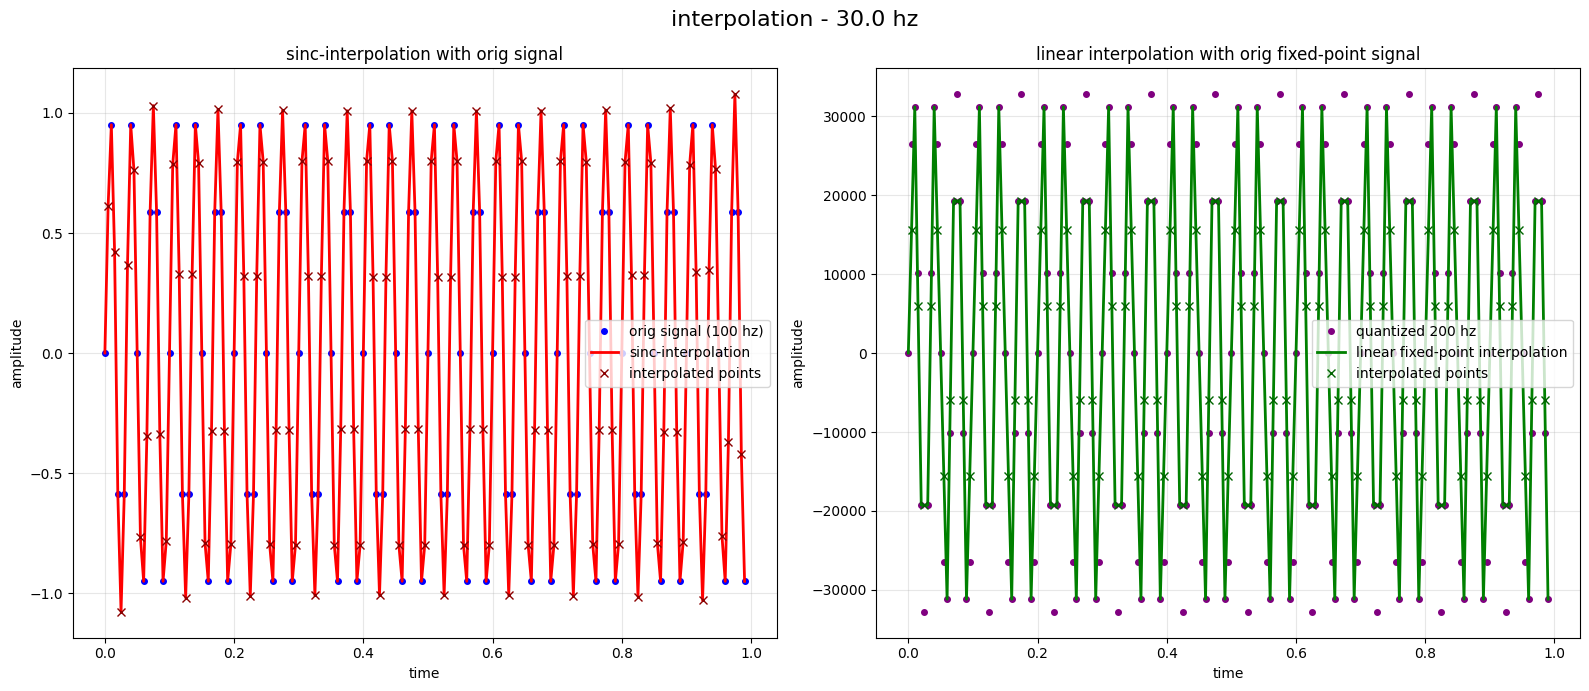

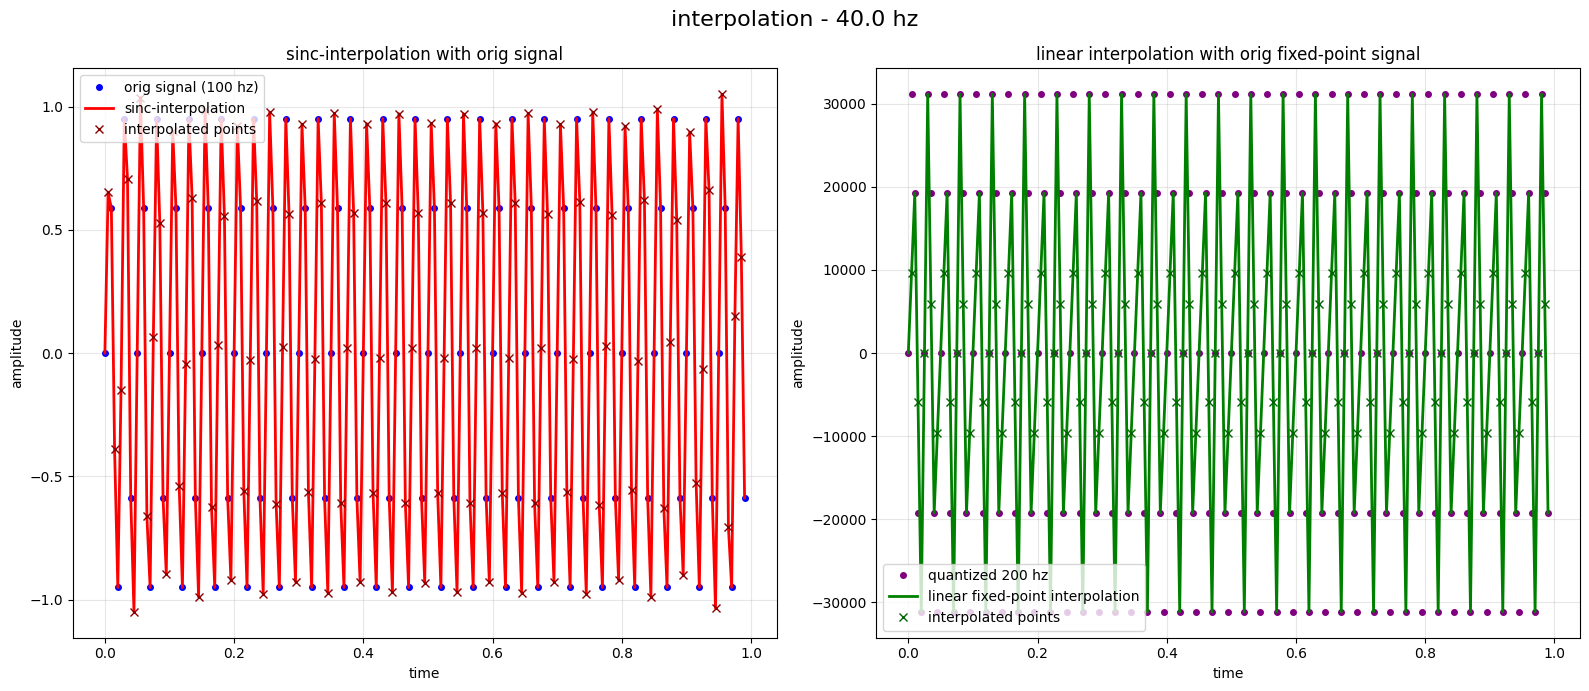

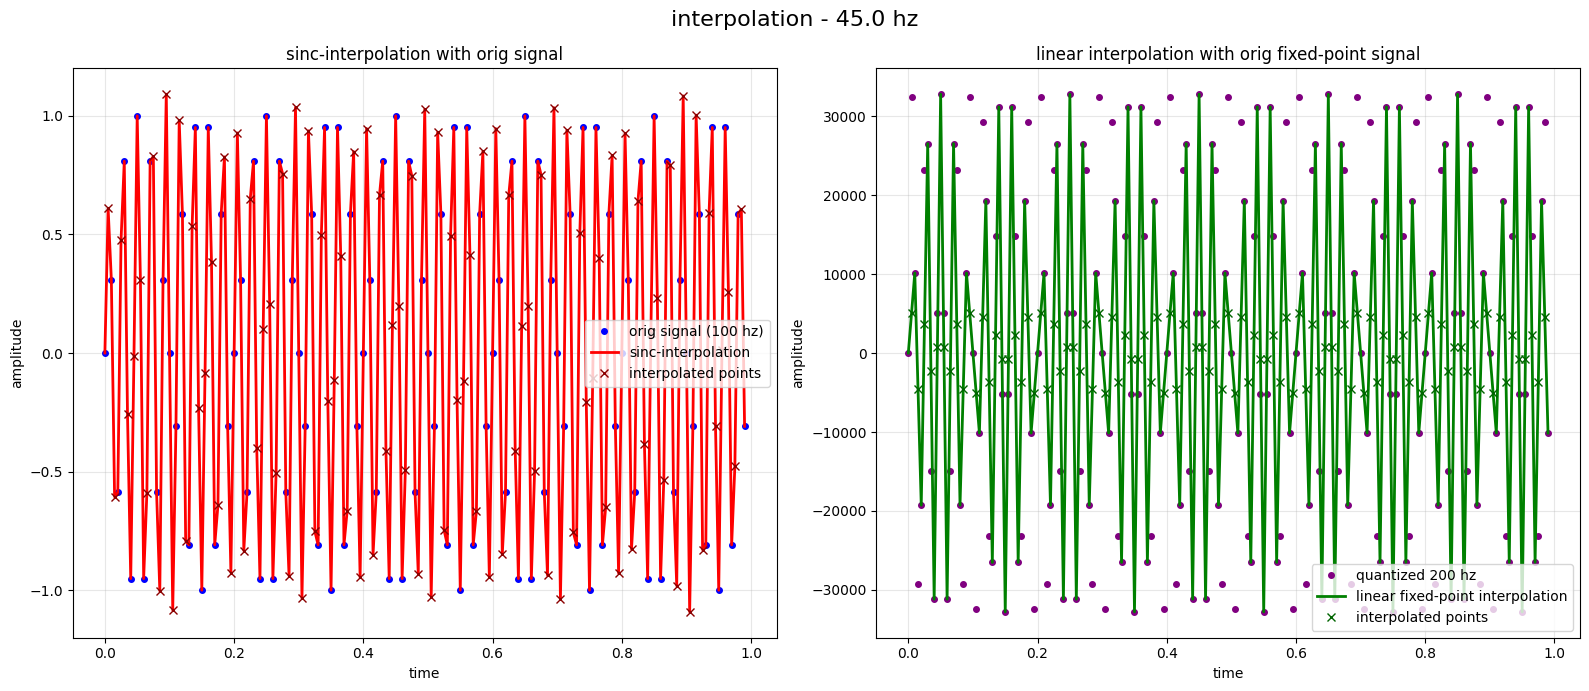

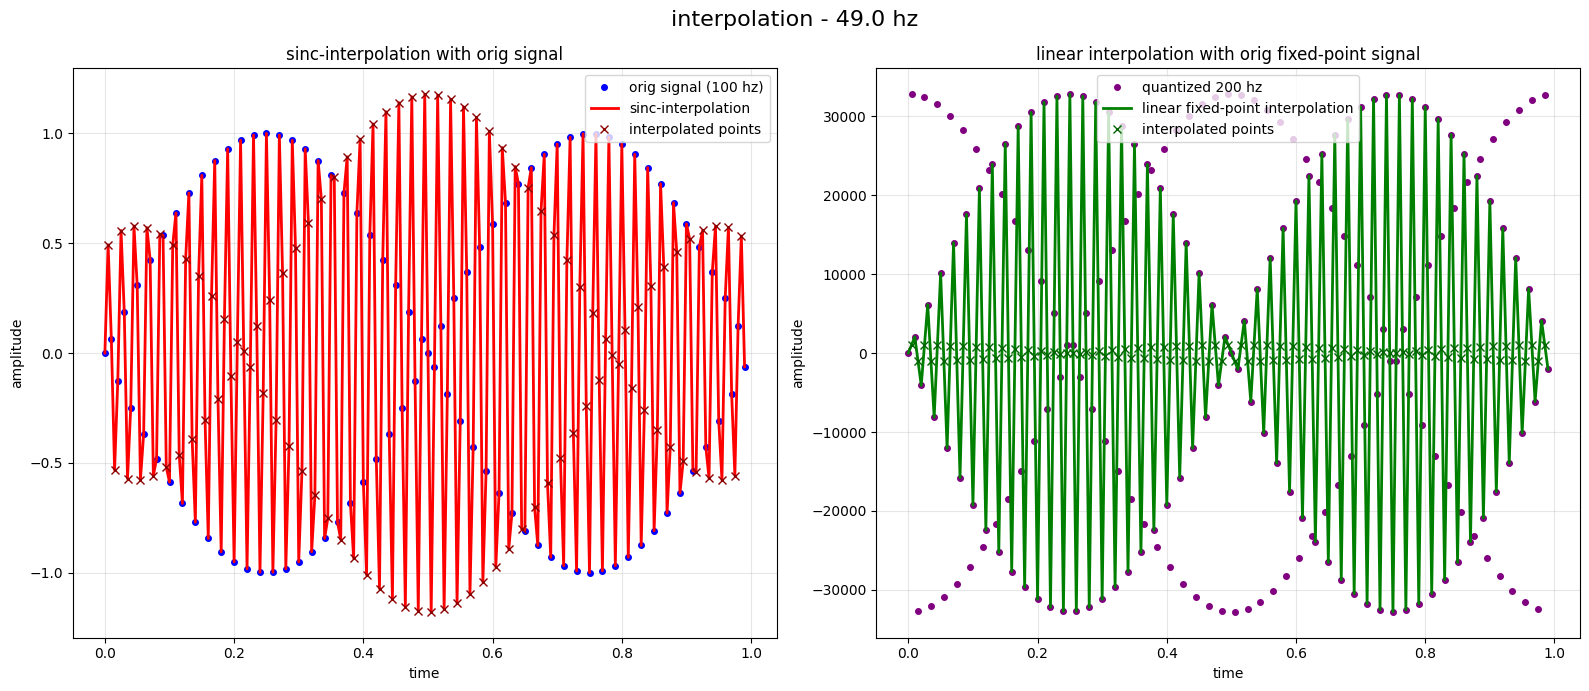

In [3]:
compare_interpolation()

Выполним БПФ для всех сигналов:

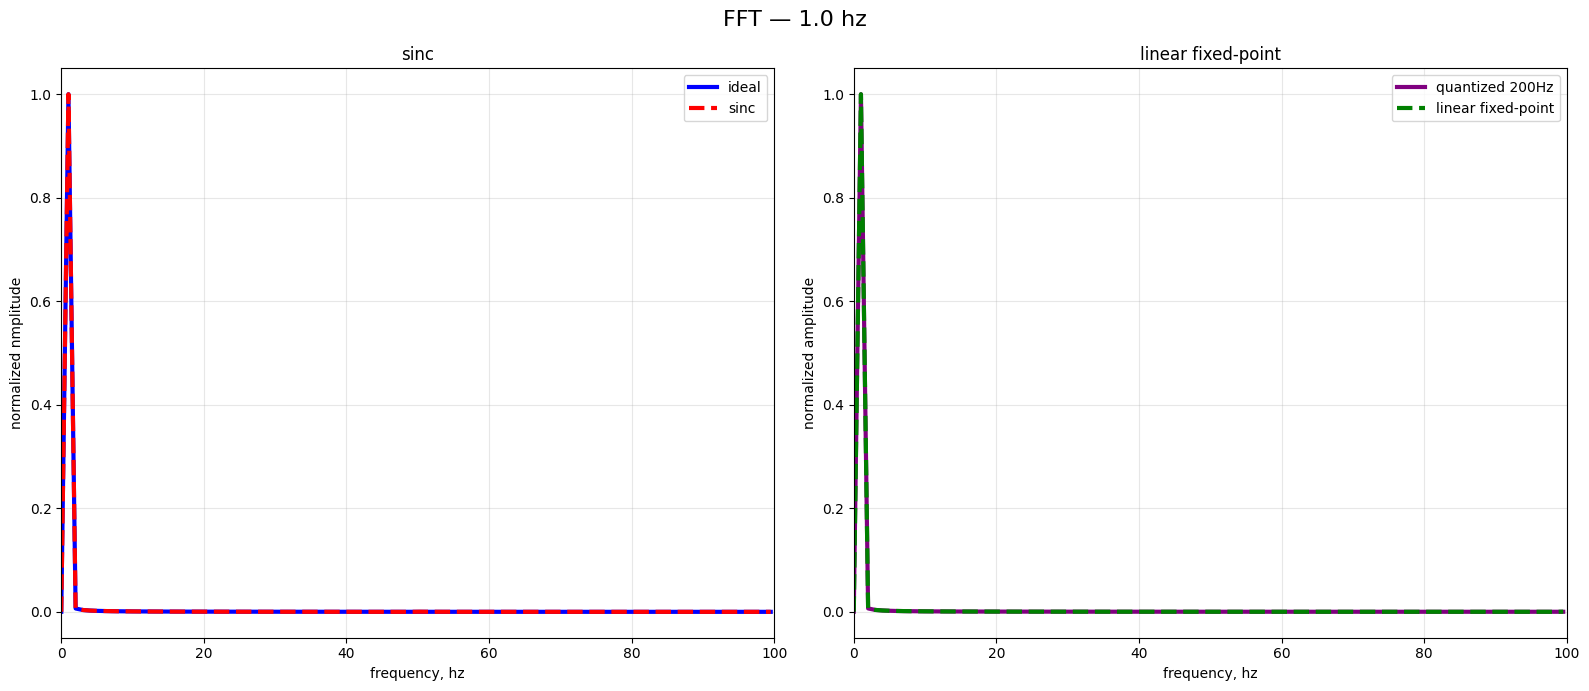

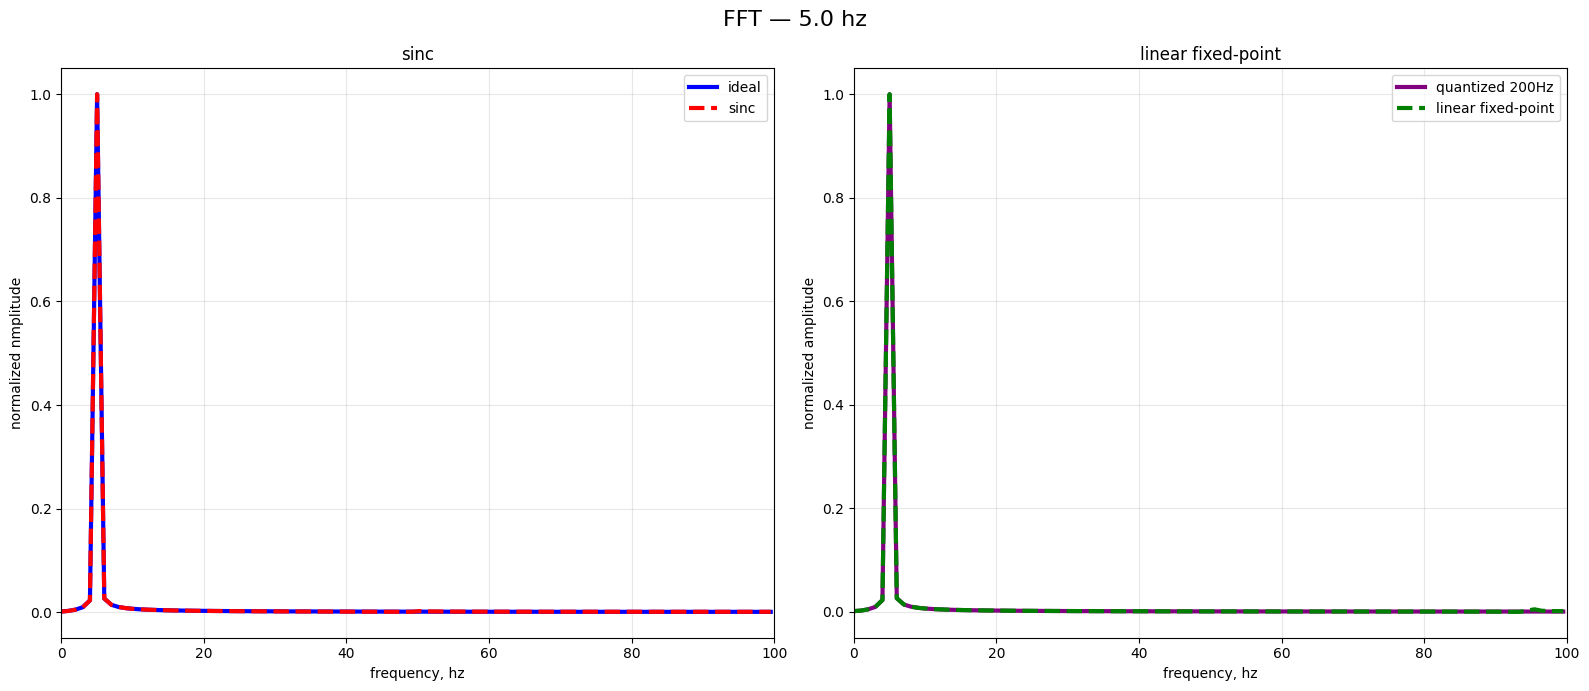

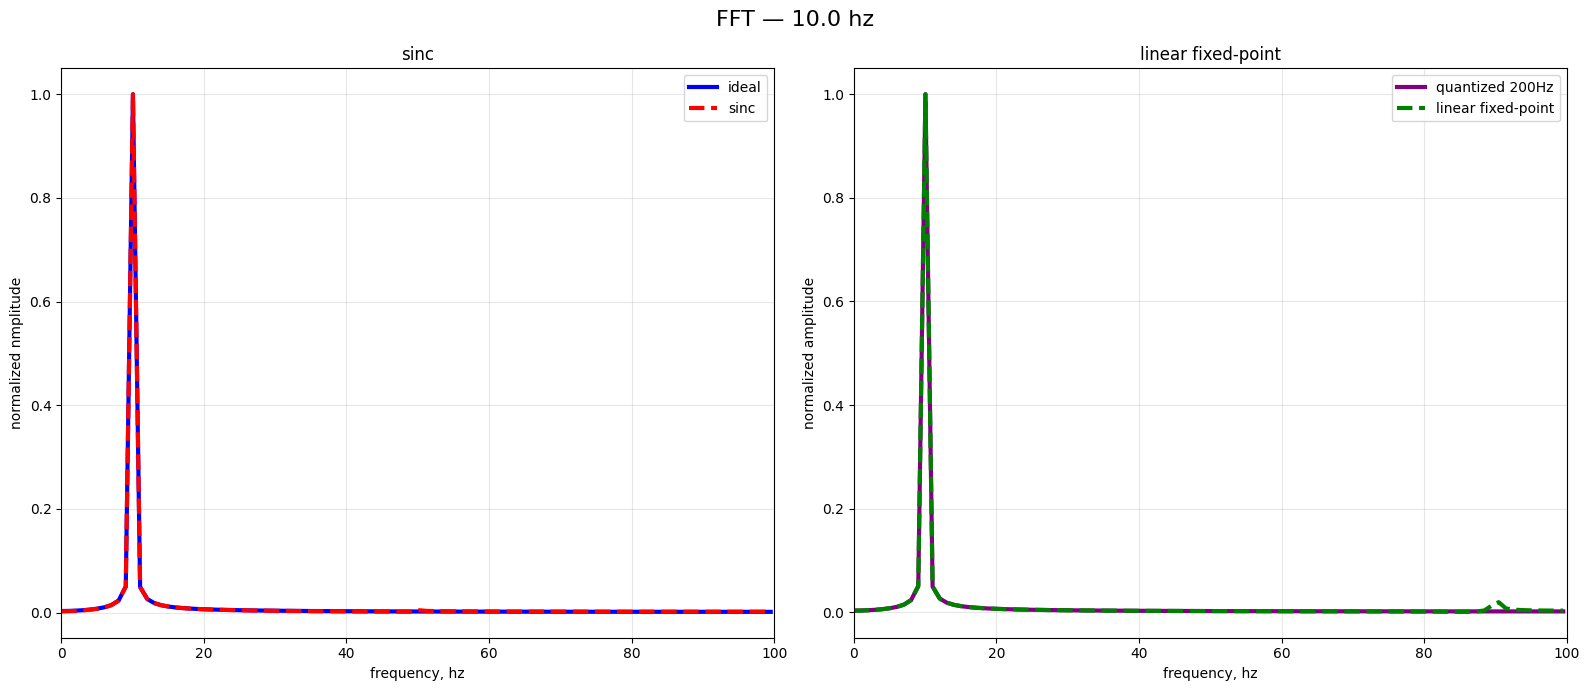

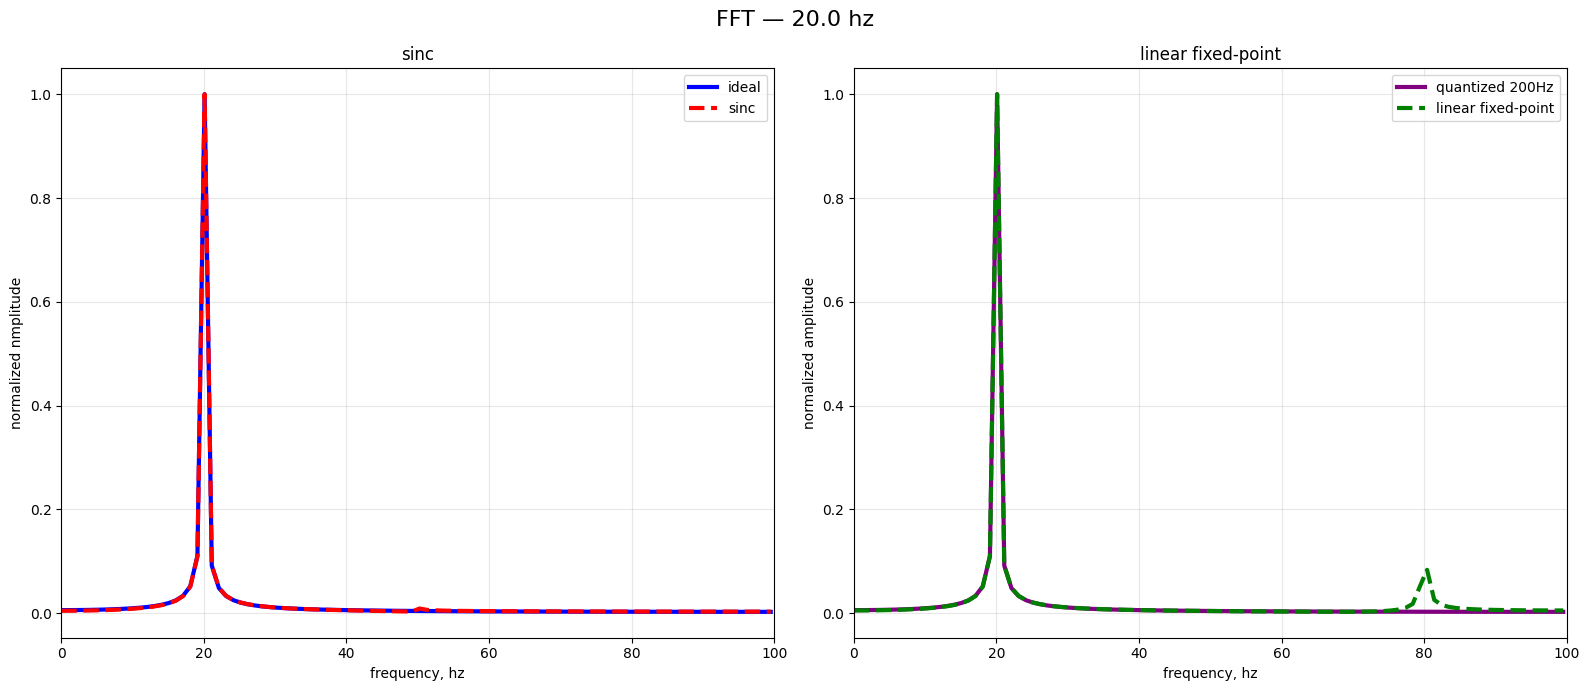

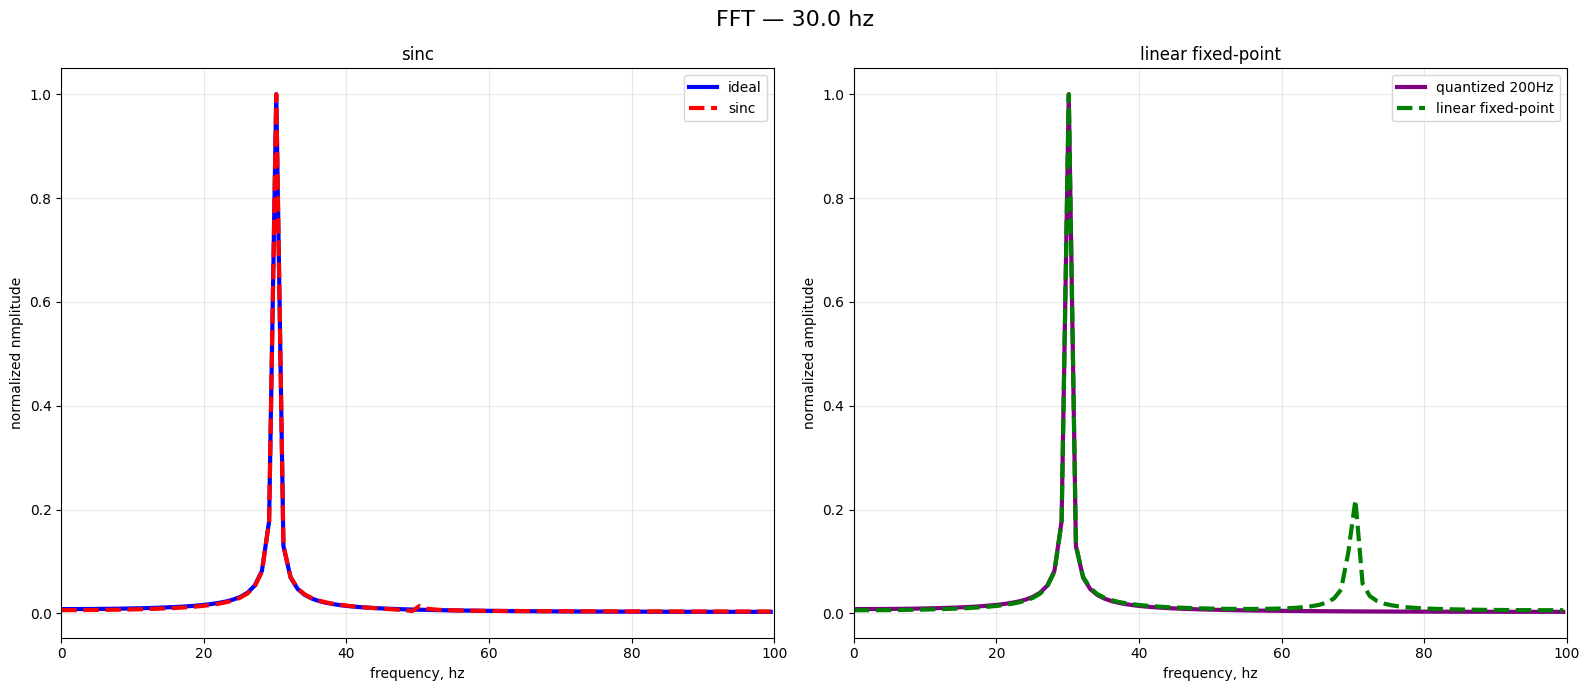

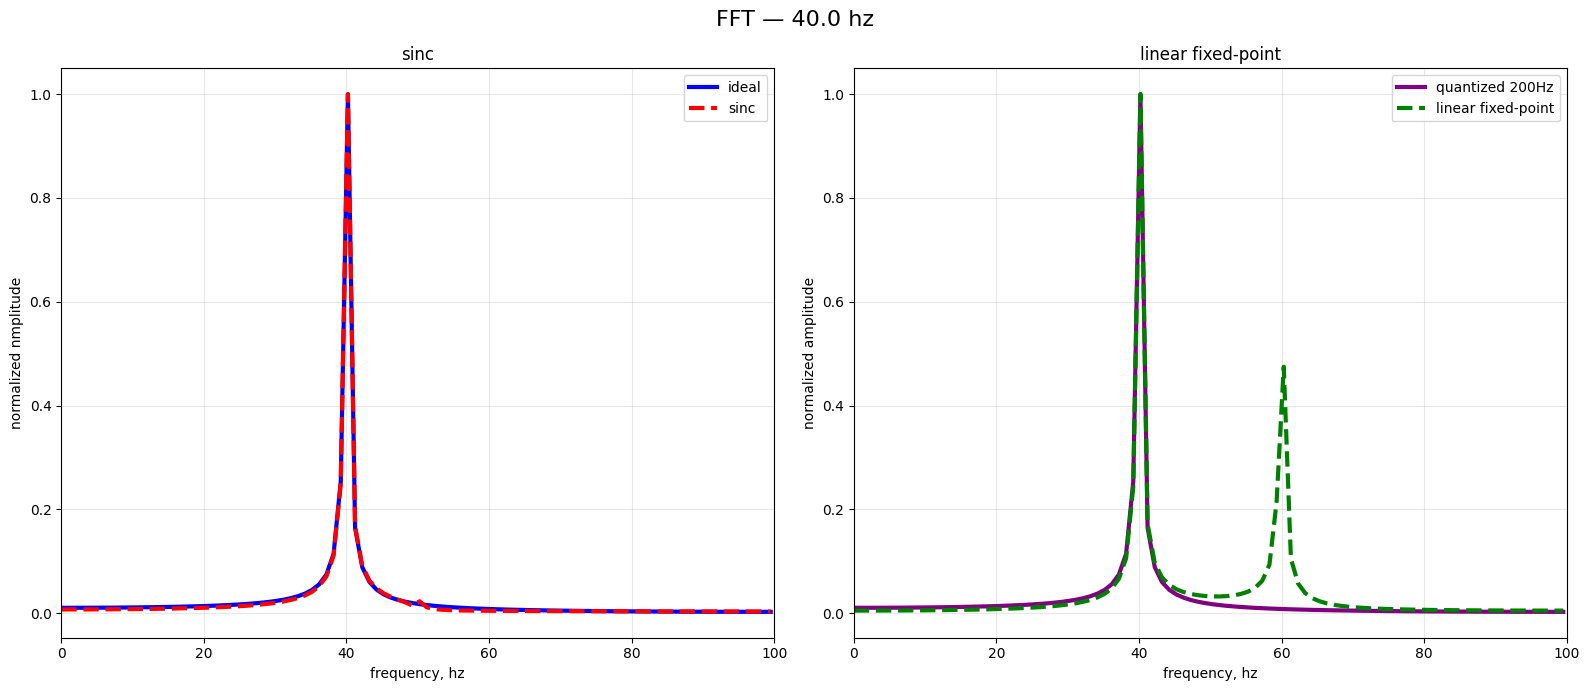

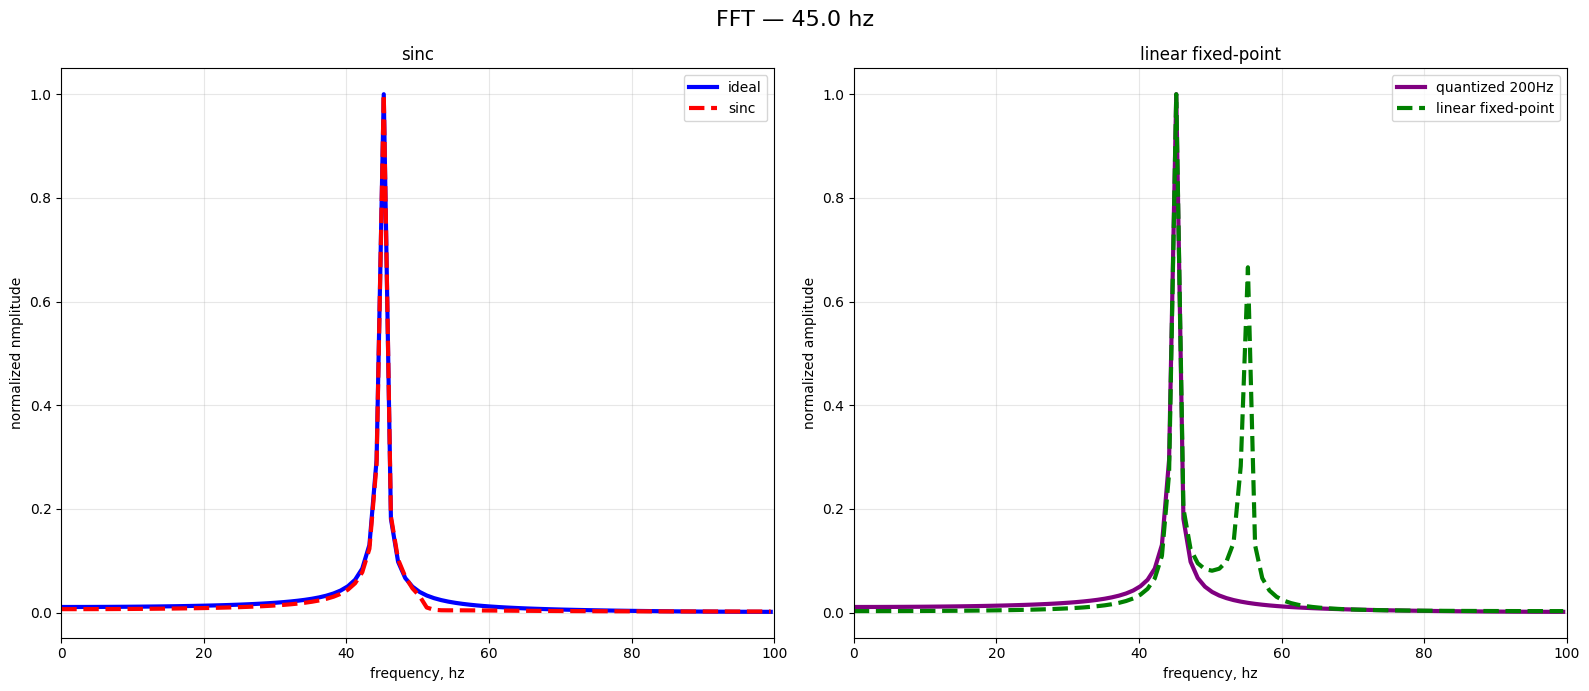

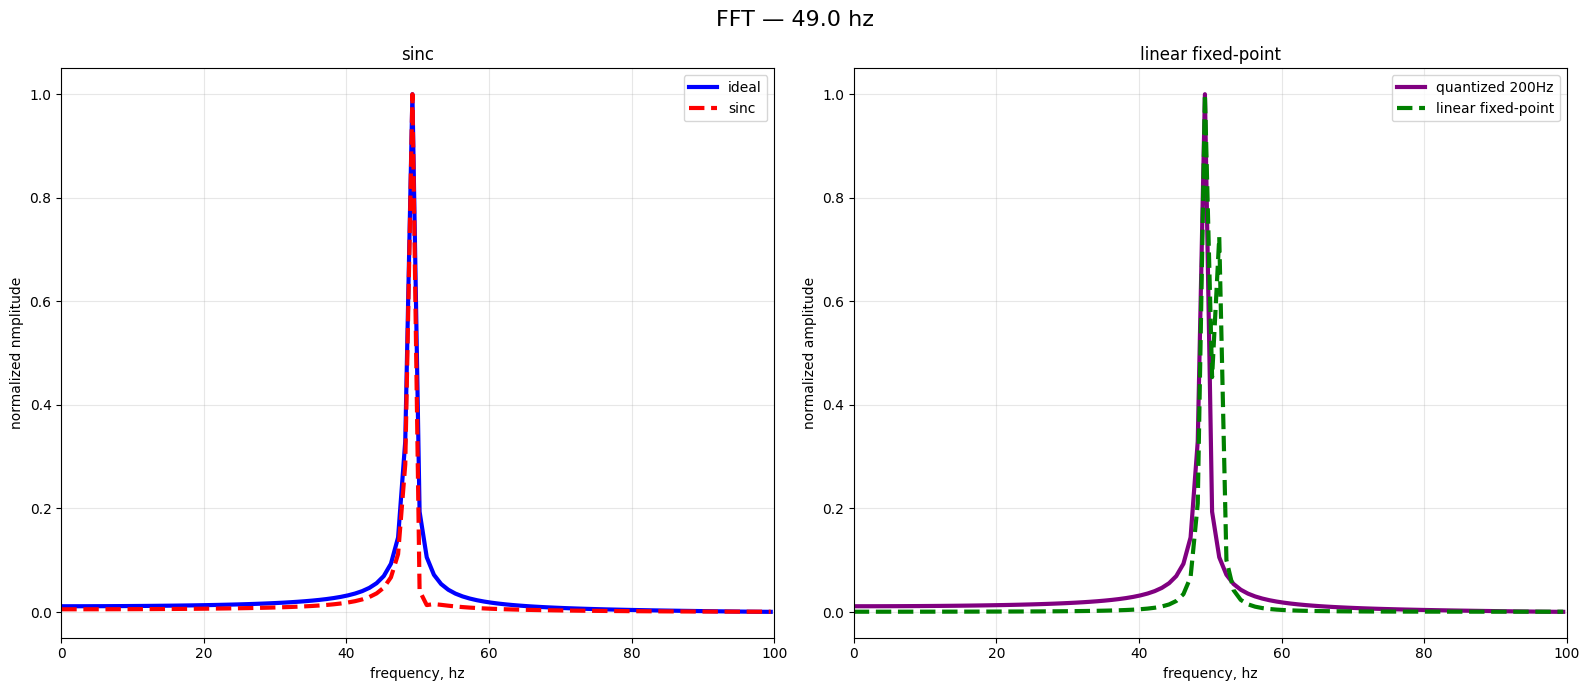

In [ ]:
plot_fft_comparison()

## Анализ по графикам
Как видим, при увеличении частоты синуса качество сигала снижается, что ожидаемо, так как частота дискретизации не меняется, и количество точек на период становится меньше с увеличением частоты синуса.

**Интерполяция**

Для синуса, вычисляемого в плавающей точке, использовалась интерполяция, основанная на теореме Найквиста-Шеннона-Котельникова. И результаты эксперимента хорошо подтверждают теоретические сведения: eсли Фурье-образ исходной функции содержится внутри отрезка $[−B, B]$, то функция может быть безошибочно восстановлена по дискретным данным, если шаг дискретизации $\delta< 1/(2B)$. На графиках мы видим, что как раз при приближении к частоте 50гц(то есть, значению $B$ из формулы с учетом дискретизации 100гц), Фурье-образ начинает искажаться. А происходит это еще до достижения частоты $B$ потому что мы ограничиваемся конечной суммой в интерполяционной формуле, то есть приближением формулы из теоремы, где сумма бесконечная.

Для синуса, вычисляемого в целых числах, использовалась линейная интерполяция. Результат интерполяции хуже. Уже при частотах от 10гц заметна дополнительная частота, амплитудла которой увеличивается с увеличением частоты синуса. Так же видно, что эта частота и основная расположены симметрично относительно частоты $B$.

**Посмотрим также на численные метрики:**

In [5]:
def compare_metrics_table(frequencies=None):
    if frequencies is None:
        frequencies = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 45.0, 49.0]
    
    results = []
    
    for freq in frequencies:
        base = f"{freq:.1f}hz_from_0.0_to_1.0"
        
        _, ideal = load_signal(base + "_ref_200")
        _, sinc = load_signal(base + "_sinc")
        _, lin_fixed = load_signal(base + "_lin_fixed")
        _, quantized = load_signal(base + "_ref_quantized_200")
        
        N = len(ideal)
        
        # Метрики
        mae_sinc = np.mean(np.abs(ideal - sinc[:N])) * 100
        max_sinc = np.max(np.abs(ideal - sinc[:N])) * 100

        max_int16_t = 32767

        mae_lin = np.mean(np.abs(quantized - lin_fixed[:N])) * 100 / max_int16_t
        max_lin = np.max(np.abs(quantized - lin_fixed[:N])) * 100 / max_int16_t
        
        results.append({
            'Частота (Гц)': freq,
            'Sinc_MAE (%)':     round(mae_sinc, 2),
            'Sinc_MaxErr (%)':  round(max_sinc, 2),
            'Lin_MAE (%)':      round(mae_lin, 2),
            'Lin_MaxErr (%)':   round(max_lin, 2),
        })
    
    df = pd.DataFrame(results)
    return df

In [6]:
compare_metrics_table()

,Частота (Гц),Sinc_MAE (%),Sinc_MaxErr (%),Lin_MAE (%),Lin_MaxErr (%)
0,1.0,0.03,0.58,0.02,0.05
1,5.0,0.13,2.89,0.40,1.22
2,10.0,0.26,5.83,1.58,4.90
3,20.0,0.57,12.14,5.85,18.16
4,30.0,1.04,19.64,13.24,41.22
5,40.0,2.13,29.92,21.04,65.72
6,45.0,3.85,37.73,26.68,83.32
7,49.0,12.14,50.70,30.51,96.81


Метрики подтвержают выводы, сделанные выше.

### Ошибка квантования

Полученные результаты (для второго теста):
```bash

time range: [0, 1]
frequencies: 1 5 10 20 30 40 45 49

Analysis
Frequency: 1 hz

[Quantization]
MAE = 8.53348e-06
Max error = 1.49526e-05

Analysis
Frequency: 5 hz

[Quantization]
MAE = 4.94099e-06
Max error = 1.34326e-05

Analysis
Frequency: 10 hz

[Quantization]
MAE = 3.77828e-06
Max error = 8.20549e-06

Analysis
Frequency: 20 hz

[Quantization]
MAE = 3.77828e-06
Max error = 8.20549e-06

Analysis
Frequency: 30 hz

[Quantization]
MAE = 3.77828e-06
Max error = 8.20549e-06

Analysis
Frequency: 40 hz

[Quantization]
MAE = 3.77828e-06
Max error = 8.20549e-06

Analysis
Frequency: 45 hz

[Quantization]
MAE = 4.94099e-06
Max error = 1.34326e-05

Analysis
Frequency: 49 hz

[Quantization]
MAE = 8.53348e-06
Max error = 1.49526e-05

```

Квантование сигнала получилось достаточно точным. Все приведенные значения ошибок выше являются абсолютными в диапазоне значения синуса $[-1,1]$ - то есть ошибка квантования на всех частотах менее 0.01%.